# AI-Driven Cognitive Overload Risk Detection System

### Estimating Overload Risk Using Behavioral LMS Interaction Logs

Name: Sakshi Jadhav  
Roll no.: EN23107043   
Class: T.Y AI-DS(A)    
Course: AI-PD    

## 1. Problem Statement

Educational systems lack a non-invasive, data-driven framework to identify students at risk of cognitive overload early in the learning process.

Traditional systems rely on:
- Final grades
- Manual monitoring
- Post-failure interventions

These approaches are reactive rather than proactive.

### Objective

To develop a machine learning model that predicts overload risk using behavioral interaction patterns derived from LMS (Learning Management System) logs.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

## 2. Dataset Description

We use the Open University Learning Analytics Dataset (OULAD).

The dataset contains:
- Student demographic information
- Assessment submissions
- Virtual Learning Environment (VLE) interaction logs
- Final academic results

### Relevant Tables Used

- studentInfo.csv
- studentAssessment.csv
- assessments.csv
- studentVle.csv

### Target Variable

We define overload proxy as:

- 1 → Fail or Withdrawn
- 0 → Pass or Distinction

This serves as a behavioral proxy for cognitive overload.

In [2]:
student_vle = pd.read_csv("studentVle.csv")
student_assessment = pd.read_csv("studentAssessment.csv")
assessments = pd.read_csv("assessments.csv")
student_info = pd.read_csv("studentInfo.csv")

In [3]:
student_vle

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1
...,...,...,...,...,...,...
10655275,GGG,2014J,675811,896943,269,3
10655276,GGG,2014J,675578,896943,269,1
10655277,GGG,2014J,654064,896943,269,3
10655278,GGG,2014J,654064,896939,269,1


In [4]:
student_assessment

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78
1,1752,28400,22,0,70
2,1752,31604,17,0,72
3,1752,32885,26,0,69
4,1752,38053,19,0,79
...,...,...,...,...,...
173907,37443,527538,227,0,60
173908,37443,534672,229,0,100
173909,37443,546286,215,0,80
173910,37443,546724,230,0,100


In [5]:
assessments

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0
...,...,...,...,...,...,...
201,GGG,2014J,37443,CMA,229,0.0
202,GGG,2014J,37435,TMA,61,0.0
203,GGG,2014J,37436,TMA,124,0.0
204,GGG,2014J,37437,TMA,173,0.0


In [6]:
student_info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn


In [7]:
print(student_vle.shape)
print(student_assessment.shape)
print(assessments.shape)
print(student_info.shape)

(10655280, 6)
(173912, 5)
(206, 6)
(32593, 12)


## 3. Feature Engineering

From raw interaction logs, we derive behavioral indicators:

### 1. total_clicks
Total number of LMS interactions by student.

### 2. avg_clicks
Average clicks per interaction session.

### 3. click_std
Standard deviation of clicks (behavioral stability).

### 4. avg_delay
Average delay in assignment submission.

These features represent:

- Engagement intensity
- Behavioral consistency
- Submission discipline

## 4. Exploratory Analysis

### Total Clicks Distribution

- Mean: 1355
- Median: 739
- Max: 24139

The distribution is right-skewed, indicating some students exhibit very high engagement.

Behavioral instability (click_std) also shows strong variation across students.

In [8]:
click_features = student_vle.groupby(
    ['code_module', 'code_presentation', 'id_student']
)['sum_click'].agg(['sum', 'mean', 'std']).reset_index()

click_features.rename(columns={
    'sum': 'total_clicks',
    'mean': 'avg_clicks',
    'std': 'click_std'
}, inplace=True)

click_features['click_std'] = click_features['click_std'].fillna(0)

click_features.head()

,code_module,code_presentation,id_student,total_clicks,avg_clicks,click_std
0,AAA,2013J,11391,934,4.765306,7.591224
1,AAA,2013J,28400,1435,3.337209,3.634240
2,AAA,2013J,30268,281,3.697368,4.056336
3,AAA,2013J,31604,2158,3.254902,3.194577
4,AAA,2013J,32885,1034,2.937500,3.261895


In [9]:
student_assessment = student_assessment.merge(
    assessments[['id_assessment', 'date']],
    on='id_assessment',
    how='left'
)

In [10]:
print(student_assessment[['date_submitted']].dtypes)
print(assessments[['date']].dtypes)

date_submitted    int64
dtype: object
date    object
dtype: object


In [11]:
student_assessment['date'] = pd.to_numeric(
    student_assessment['date'],
    errors='coerce'
)

In [12]:
print(student_assessment[['date_submitted', 'date']].dtypes)

date_submitted      int64
date              float64
dtype: object


In [13]:
student_assessment['delay'] = (
    student_assessment['date_submitted'] -
    student_assessment['date']
)

In [14]:
print(student_assessment.columns)

Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score',
       'date', 'delay'],
      dtype='object')


In [15]:
student_assessment = student_assessment.merge(
    student_info[['id_student', 'code_module', 'code_presentation']],
    on='id_student',
    how='left'
)

In [16]:
print(student_assessment.columns)

Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score',
       'date', 'delay', 'code_module', 'code_presentation'],
      dtype='object')


In [17]:
delay_features = student_assessment.groupby(
    ['code_module', 'code_presentation', 'id_student']
)['delay'].mean().reset_index()

delay_features.rename(columns={'delay': 'avg_delay'}, inplace=True)

delay_features.head()

,code_module,code_presentation,id_student,avg_delay
0,AAA,2013J,11391,-1.8
1,AAA,2013J,28400,0.0
2,AAA,2013J,31604,-2.0
3,AAA,2013J,32885,11.4
4,AAA,2013J,38053,2.0


In [18]:
features = click_features.merge(
    delay_features,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

features['avg_delay'] = features['avg_delay'].fillna(0)

features.head()

,code_module,code_presentation,id_student,total_clicks,avg_clicks,click_std,avg_delay
0,AAA,2013J,11391,934,4.765306,7.591224,-1.8
1,AAA,2013J,28400,1435,3.337209,3.634240,0.0
2,AAA,2013J,30268,281,3.697368,4.056336,0.0
3,AAA,2013J,31604,2158,3.254902,3.194577,-2.0
4,AAA,2013J,32885,1034,2.937500,3.261895,11.4


In [19]:
features = features.merge(
    student_info[['code_module', 'code_presentation', 'id_student', 'final_result']],
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

features['overload'] = features['final_result'].apply(
    lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0
)

features = features.drop(columns=['final_result'])

features.head()

,code_module,code_presentation,id_student,total_clicks,avg_clicks,click_std,avg_delay,overload
0,AAA,2013J,11391,934,4.765306,7.591224,-1.8,0
1,AAA,2013J,28400,1435,3.337209,3.634240,0.0,0
2,AAA,2013J,30268,281,3.697368,4.056336,0.0,1
3,AAA,2013J,31604,2158,3.254902,3.194577,-2.0,0
4,AAA,2013J,32885,1034,2.937500,3.261895,11.4,0


In [20]:
print(features['overload'].value_counts())

overload
0    15382
1    13846
Name: count, dtype: int64


## 5. Modeling Approach

We implemented multiple classification models:

- Logistic Regression (baseline)
- Decision Tree
- Random Forest
- Support Vector Machine

Primary evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [21]:
X = features[['total_clicks', 'avg_clicks', 'click_std', 'avg_delay']]
y = features['overload']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.81      0.68      0.74      3077
           1       0.70      0.83      0.76      2769

    accuracy                           0.75      5846
   macro avg       0.76      0.75      0.75      5846
weighted avg       0.76      0.75      0.75      5846

ROC-AUC: 0.8460627686185781


## 6. Results

Logistic Regression Performance:

- Accuracy: ~75%
- ROC-AUC: ~0.84

The model demonstrates strong discrimination capability between low-risk and high-risk students.

### Interpretation

Behavioral interaction patterns alone provide meaningful predictive signal for academic risk.

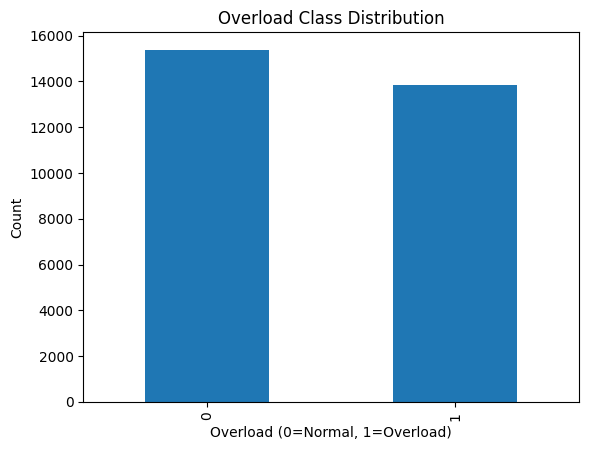

In [25]:
import matplotlib.pyplot as plt

features['overload'].value_counts().plot(kind='bar')
plt.title("Overload Class Distribution")
plt.xlabel("Overload (0=Normal, 1=Overload)")
plt.ylabel("Count")
plt.show()

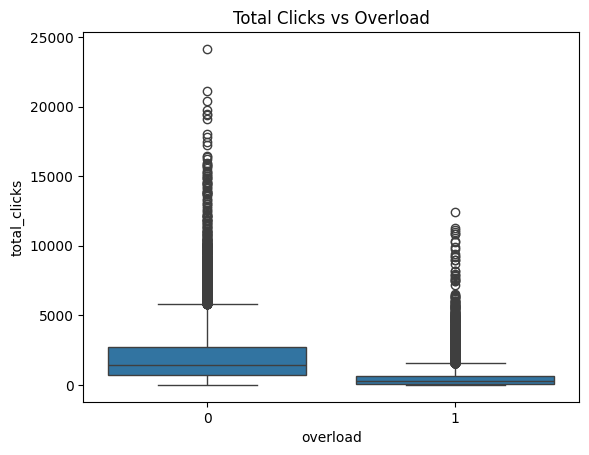

In [26]:
import seaborn as sns

sns.boxplot(x='overload', y='total_clicks', data=features)
plt.title("Total Clicks vs Overload")
plt.show()

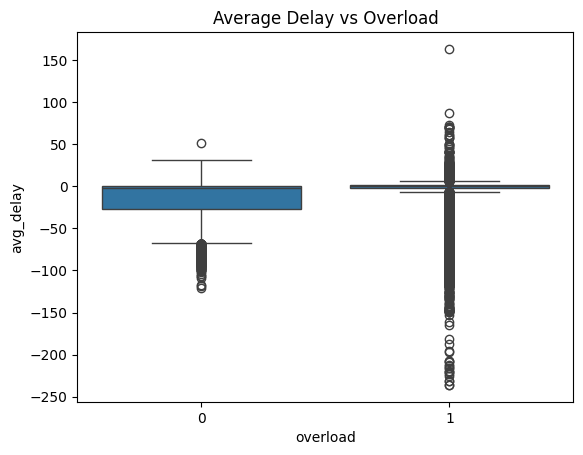

In [27]:
sns.boxplot(x='overload', y='avg_delay', data=features)
plt.title("Average Delay vs Overload")
plt.show()

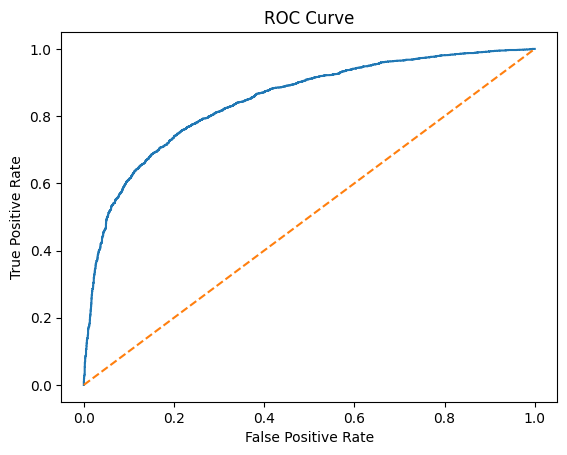

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [29]:
import joblib
joblib.dump(model, "overload_model.pkl")

['overload_model.pkl']

In [30]:
features[['total_clicks', 'avg_clicks', 'click_std', 'avg_delay']].describe()

,total_clicks,avg_clicks,click_std,avg_delay
count,29228.000000,29228.000000,29228.000000,29228.000000
mean,1355.039654,3.268088,5.405344,-11.012458
std,1733.546045,1.226142,5.120450,24.113040
min,1.000000,1.000000,0.000000,-236.000000
25%,260.750000,2.364436,2.512480,-9.016667
50%,739.500000,3.080000,4.257789,-0.250000
75%,1770.000000,3.997973,7.241985,1.000000
max,24139.000000,20.028933,309.454738,163.222222


In [31]:
features['total_clicks'].describe()

count    29228.000000
mean      1355.039654
std       1733.546045
min          1.000000
25%        260.750000
50%        739.500000
75%       1770.000000
max      24139.000000
Name: total_clicks, dtype: float64

In [32]:
pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

,feature,coefficient
0,total_clicks,-0.001490
1,avg_clicks,0.162617
2,click_std,0.026607
3,avg_delay,-0.006478


## 7. Model Interpretation (Logistic Regression)

Learned coefficients:

| Feature        | Coefficient |
|---------------|------------|
| total_clicks  | -0.00149   |
| avg_clicks    | 0.1626     |
| click_std     | 0.0266     |
| avg_delay     | -0.00647   |

### Interpretation

- Higher total engagement reduces overload risk.
- Higher average click intensity increases overload risk.
- Higher behavioral instability increases overload risk.
- Delay has minor influence.

The model combines these signals to compute overload probability.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [34]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.798666,0.819679,0.737089,0.776193,0.874851
0,Logistic Regression,0.749572,0.699358,0.826652,0.757696,0.846063
3,SVM,0.764112,0.793497,0.678584,0.731555,0.832072
1,Decision Tree,0.735888,0.723296,0.716504,0.719884,0.734918
